Companion notebook for *A Probabilistic Mixture Model for Evaluating Sound Localisation Performance in the Median Plane* (Sztandera, Picinali, Barumerli, Forum Acusticum 2026). Run it from the repository root; it reads `data/AXD_measured.csv` (see `data/README.md`).

# Where QE and PE fail — and where the mixture model works

Synthetic median-plane listeners with **known** confusion rate `1 − w` and polar scatter `σ`.
Each listener is scored three ways:

| Metric | Function | What it does |
|---|---|---|
| **QE** — quadrant error (%) | `querrMiddlebrooks` | counts responses with \|polar error\| ≥ 90° |
| **PE** — local polar RMS (°) | `rmsPmedianlocal` | RMS of the polar errors that are < 90° |
| **Mixture** — `1 − ŵ`, `σ̂` | `mixture_model` (2-parameter, `use_prior=False`) | MLE of the von Mises front/back mixture on *all* responses |

QE and PE both hinge on the same hard 90° threshold. Every figure below is a **median-plane scatter**
(polar target vs polar response). Responses that QE counts as a confusion are drawn in orange; the dashed
line is the identity, the dotted line is the front–back mirror `φ_r = 180° − φ_t`.

Four failure modes are shown:

1. **Scatter is not confusion** — a listener with *zero* confusions gets a rising QE and a saturating PE as σ grows.
2. **Confusions that never cross 90°** — the *same* listener gets QE = 0 % on elevated targets and QE ≈ 40 % on targets near the horizon.
3. **Two different listeners, one classical fingerprint** — matched QE/PE, different `(w, σ)`.
4. **Sweep** — bias of each metric over the whole `(w, σ)` plane.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from metrics import querrMiddlebrooks, rmsPmedianlocal, mixture_model, wrap_polar_angle
from bayesian_metric import sigma_to_kappa, polar_mirror

SEED   = 42
N_TRIALS = 120           # comparable to the larger AXD participants (45–123 central trials)
rng    = np.random.default_rng(SEED)

# Colours shared with 4_axd_prior.ipynb
C_BLUE, C_TEAL, C_ORANGE = '#0d40a5', '#157979', '#c75605'
plt.rcParams.update({'font.size': 9})

# Polar-target pool: AXD central targets (|lat| ≤ 30°), used as the median-plane grid
data_file = 'data/AXD_measured.csv'   # Measured condition only
if os.path.exists(data_file):
    obs_tbl = pd.read_csv(data_file)
    obs_tbl = obs_tbl[obs_tbl['participant'] != 'P0247']
    TARGET_POOL = obs_tbl.loc[np.abs(obs_tbl['lat_target']) <= 30.0, 'pol_target'].round().values
else:  # fallback: the same 9-point grid, equal weights
    TARGET_POOL = np.repeat(np.arange(-30, 211, 30), 50).astype(float)

print('Target grid (deg) and relative frequency:')
print(pd.Series(TARGET_POOL).value_counts(normalize=True).sort_index().round(3).to_string())

Target grid (deg) and relative frequency:
-30.0     0.073
 0.0      0.195
 30.0     0.073
 60.0     0.073
 90.0     0.172
 120.0    0.073
 150.0    0.073
 180.0    0.195
 210.0    0.073


## Helpers — simulate, score, plot

In [2]:
def simulate(w, sigma, pol_targets_deg, rng):
    '''Median-plane listener: response ~ w·VM(φ_t, κ) + (1−w)·VM(180°−φ_t, κ).
    Returns (true_hp, est_hp) as (n, 2) [lateral, polar] arrays in radians, lateral = 0.'''
    n     = len(pol_targets_deg)
    kappa = sigma_to_kappa(sigma)
    pt    = wrap_polar_angle(np.deg2rad(pol_targets_deg))
    mu    = np.where(rng.random(n) < w, pt, polar_mirror(pt))
    pr    = wrap_polar_angle(rng.vonmises(mu, kappa))
    lat   = np.zeros(n)
    return np.column_stack([lat, pt]), np.column_stack([lat, pr])


def score(true_hp, est_hp):
    '''QE (%), PE (deg), mixture confusion (%) and sigma (deg).'''
    qe, _   = querrMiddlebrooks(true_hp, est_hp)
    pe, _   = rmsPmedianlocal(true_hp, est_hp)
    mix, _  = mixture_model(true_hp, est_hp, use_prior=False)
    return dict(QE=qe, PE=np.rad2deg(pe), conf_mix=100 * (1 - mix[0]), sigma_mix=mix[1])


def plot_median_plane(ax, true_hp, est_hp, title, w=None, sigma=None, res=None,
                      jitter=4.0, rng=None):
    '''Scatter polar target vs polar response. Orange = counted as QE (|error| ≥ 90°).'''
    rng   = np.random.default_rng(0) if rng is None else rng
    pol_t = np.rad2deg(true_hp[:, 1])
    pol_r = np.rad2deg(est_hp[:, 1])
    err   = np.rad2deg(np.abs(wrap_polar_angle(est_hp[:, 1] - true_hp[:, 1]) ))
    err   = np.minimum(err, 360 - err)
    is_qe = err >= 90
    x     = pol_t + rng.uniform(-jitter, jitter, len(pol_t))

    ax.plot([-90, 270], [-90, 270], 'k--', lw=0.8, alpha=0.6, zorder=1)
    ax.plot([-90, 270], [270, -90], 'k:',  lw=0.8, alpha=0.6, zorder=1)
    ax.scatter(x[~is_qe], pol_r[~is_qe], s=18, color=C_TEAL,   edgecolors='k', linewidths=0.3,
               zorder=3, label='counted by PE')
    ax.scatter(x[is_qe],  pol_r[is_qe],  s=18, color=C_ORANGE, edgecolors='k', linewidths=0.3,
               zorder=3, label='counted by QE')
    ax.set_xlim(-45, 225); ax.set_ylim(-90, 270)
    ax.set_xticks(np.arange(-30, 211, 60)); ax.set_yticks(np.arange(-90, 271, 90))
    ax.set_xlabel('Polar target (°)'); ax.set_ylabel('Polar response (°)')
    ax.set_aspect('equal')
    ax.spines[['top', 'right']].set_visible(False)
    if res is None:
        ax.set_title(title, fontsize=9)
    else:
        stats = (f'true     conf {100*(1-w):3.0f} %   σ  {sigma:3.0f}°\n'
                 f'QE / PE  conf {res["QE"]:3.0f} %   PE {res["PE"]:3.0f}°\n'
                 f'mixture  conf {res["conf_mix"]:3.0f} %   σ̂  {res["sigma_mix"]:3.0f}°')
        ax.set_title(title + '\n' + stats, fontsize=8, family='monospace', loc='left')

## 1. Scatter is not confusion

Same listener, **w = 1** (never confuses front and back), scatter σ growing from 15° to 55°.
As σ grows, more responses spill past the 90° threshold: QE reports confusions that do not exist,
and PE saturates because the largest errors are removed from its RMS. The mixture keeps `1 − ŵ ≈ 0`
and tracks σ.

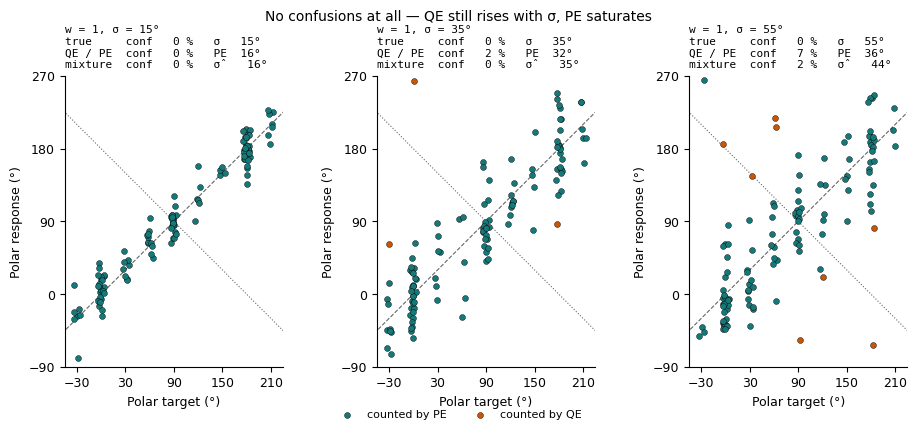

In [3]:
sigmas_A = [15, 35, 55]
fig, axes = plt.subplots(1, 3, figsize=(9.5, 4.2))
for ax, sigma in zip(axes, sigmas_A):
    pol_t = rng.choice(TARGET_POOL, N_TRIALS)
    t, e  = simulate(1.0, sigma, pol_t, rng)
    res   = score(t, e)
    plot_median_plane(ax, t, e, f'w = 1, σ = {sigma}°', w=1.0, sigma=sigma, res=res, rng=rng)
h, l = axes[-1].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=2, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('No confusions at all — QE still rises with σ, PE saturates', fontsize=10)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

## 2. Confusions that never cross the 90° threshold

QE can only see a front–back confusion if the mirrored response lies ≥ 90° from the target.
For a target at 60° the mirror is at 120°: a 60° error, invisible to QE and fully absorbed by PE.
For a target at 90° the mirror *is* the target.

Same listener (**w = 0.6, σ = 10°**, i.e. 40 % confusions) tested on three target sets.

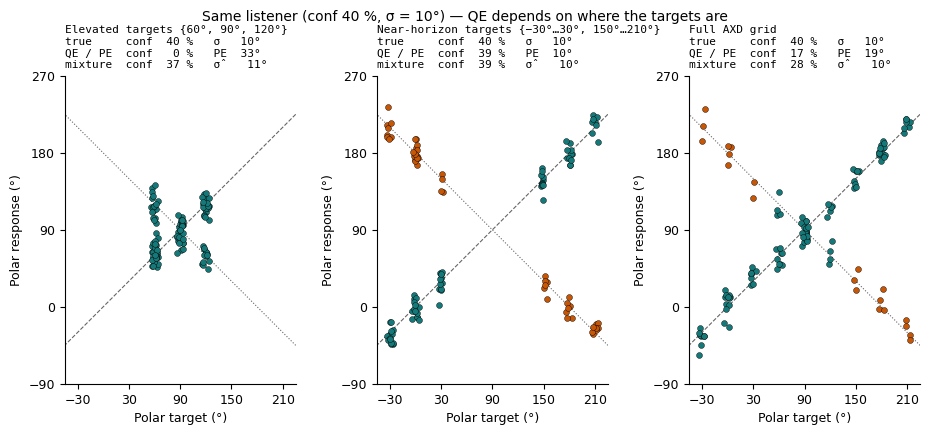

In [4]:
target_sets = {
    'Elevated targets {60°, 90°, 120°}':        np.array([60., 90., 120.]),
    'Near-horizon targets {−30°…30°, 150°…210°}': np.array([-30., 0., 30., 150., 180., 210.]),
    'Full AXD grid':                            np.unique(TARGET_POOL),
}
w_B, sigma_B = 0.6, 10.0

fig, axes = plt.subplots(1, 3, figsize=(9.5, 4.2))
for ax, (name, grid) in zip(axes, target_sets.items()):
    pol_t = rng.choice(grid, N_TRIALS)
    t, e  = simulate(w_B, sigma_B, pol_t, rng)
    res   = score(t, e)
    plot_median_plane(ax, t, e, name, w=w_B, sigma=sigma_B, res=res, rng=rng)
fig.suptitle(f'Same listener (conf {100*(1-w_B):.0f} %, σ = {sigma_B:.0f}°) — QE depends on where the targets are',
             fontsize=10)
plt.tight_layout(); plt.show()

## 3. Two different listeners, one classical fingerprint

Listener **A**: w = 1.0, σ = 55° (never confuses, very imprecise).
Listener **B**: w = 0.9, σ = 45° (10 % confusions, less imprecise).

Their expected QE and PE coincide within sampling noise (see the contour map in §4). Over 30 replicate
sessions of 120 trials, the classical metrics cannot tell A from B; the mixture separates them.

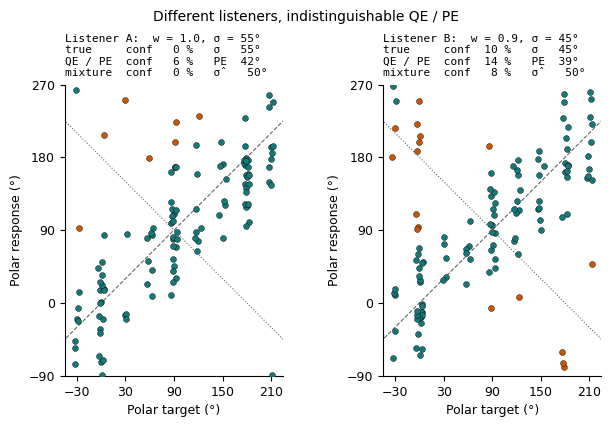

            QE         PE      conf_mix      sigma_mix     
          mean  std  mean  std     mean  std      mean  std
listener                                                   
A         11.1  3.8  41.3  2.3      1.6  2.4      54.1  5.0
B         11.2  2.8  39.4  3.0      9.2  3.9      46.4  5.1


In [5]:
listeners = {'A': (1.0, 55.0), 'B': (0.9, 45.0)}
N_REP_C   = 30

# One example session each — median-plane scatter
fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.2))
example = {}
for ax, (name, (w, s)) in zip(axes, listeners.items()):
    pol_t = rng.choice(TARGET_POOL, N_TRIALS)
    t, e  = simulate(w, s, pol_t, rng)
    res   = score(t, e)
    example[name] = res
    plot_median_plane(ax, t, e, f'Listener {name}:  w = {w}, σ = {s:.0f}°', w=w, sigma=s, res=res, rng=rng)
fig.suptitle('Different listeners, indistinguishable QE / PE', fontsize=10)
plt.tight_layout(); plt.show()

# Replicates
def _one_rep(w, s, seed):
    r = np.random.default_rng(seed)
    t, e = simulate(w, s, r.choice(TARGET_POOL, N_TRIALS), r)
    return score(t, e)

rep_rows = []
for name, (w, s) in listeners.items():
    seeds = rng.integers(0, 2**31, N_REP_C)
    out   = joblib.Parallel(n_jobs=-1)(joblib.delayed(_one_rep)(w, s, int(sd)) for sd in seeds)
    for o in out:
        rep_rows.append(dict(listener=name, **o))
rep_df = pd.DataFrame(rep_rows)
print(rep_df.groupby('listener').agg(['mean', 'std']).round(1).to_string())

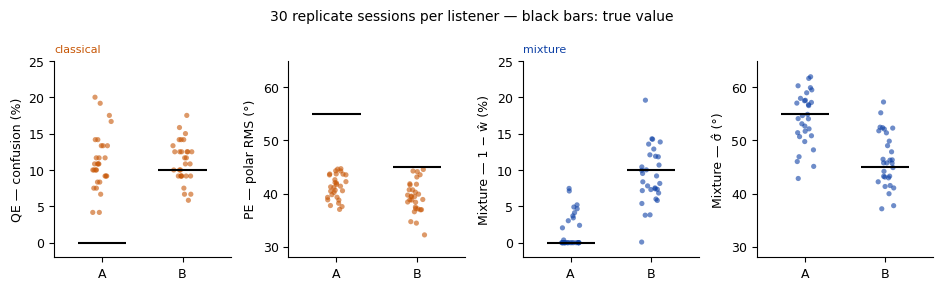

In [6]:
panels = [
    ('QE',        'QE — confusion (%)',       'A: 0 %   B: 10 %'),
    ('PE',        'PE — polar RMS (°)',        'A: 55°   B: 45°'),
    ('conf_mix',  'Mixture — 1 − ŵ (%)',       'A: 0 %   B: 10 %'),
    ('sigma_mix', 'Mixture — σ̂ (°)',           'A: 55°   B: 45°'),
]
truth = {'QE': {'A': 0, 'B': 10}, 'PE': {'A': 55, 'B': 45},
         'conf_mix': {'A': 0, 'B': 10}, 'sigma_mix': {'A': 55, 'B': 45}}

fig, axes = plt.subplots(1, 4, figsize=(9.5, 2.9))
for ax, (col, ylabel, _) in zip(axes, panels):
    for i, name in enumerate(listeners):
        y = rep_df.loc[rep_df['listener'] == name, col].values
        x = i + rng.uniform(-0.12, 0.12, len(y))
        ax.scatter(x, y, s=14, color=C_BLUE if col.endswith('mix') else C_ORANGE,
                   alpha=0.6, edgecolors='none', zorder=3)
        ax.hlines(truth[col][name], i - 0.3, i + 0.3, color='k', lw=1.5, zorder=4)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['A', 'B']); ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(ylabel)
    ax.set_ylim((-2, 25) if col in ('QE', 'conf_mix') else (28, 65))
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_title('classical', loc='left', fontsize=8, color=C_ORANGE)
axes[2].set_title('mixture',   loc='left', fontsize=8, color=C_BLUE)
fig.suptitle(f'{N_REP_C} replicate sessions per listener — black bars: true value', fontsize=10)
plt.tight_layout(); plt.show()

## 4. Sweep over the (w, σ) plane

**Left / middle:** expected QE and PE (large-N simulation, no fitting) as contours over true confusion rate
and true σ. Where contour lines run *diagonally* the two metrics leak into each other: QE grows with σ,
PE bends with w and flattens above ~40°. Listeners A and B from §3 sit on the same QE and PE contours.

**Right block:** bias of each estimator across the same plane, from `N_REP_D` fitted sessions per cell.

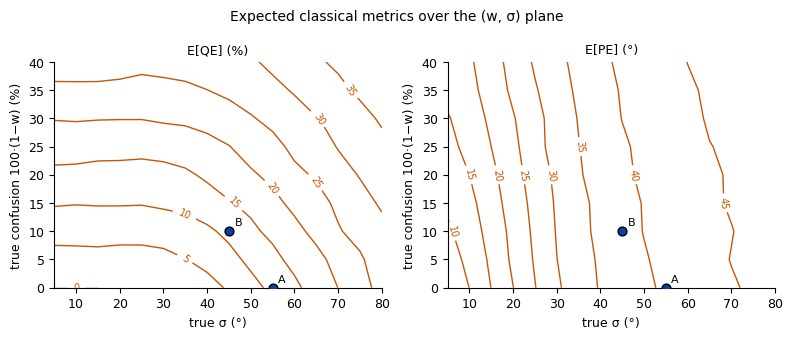

In [7]:
w_grid     = np.round(np.arange(0.60, 1.001, 0.05), 2)
sigma_grid = np.arange(5, 81, 5, dtype=float)
N_BIG      = 20000

def _expected(w, s, seed):
    r = np.random.default_rng(seed)
    t, e = simulate(w, s, r.choice(TARGET_POOL, N_BIG), r)
    return querrMiddlebrooks(t, e)[0], np.rad2deg(rmsPmedianlocal(t, e)[0])

jobs = [(w, s) for w in w_grid for s in sigma_grid]
exp_out = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(_expected)(w, s, SEED + i) for i, (w, s) in enumerate(jobs))
E_QE = np.array([o[0] for o in exp_out]).reshape(len(w_grid), len(sigma_grid))
E_PE = np.array([o[1] for o in exp_out]).reshape(len(w_grid), len(sigma_grid))
conf_grid = 100 * (1 - w_grid)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, Z, lbl, levels in zip(axes, [E_QE, E_PE], ['E[QE] (%)', 'E[PE] (°)'],
                              [np.arange(0, 41, 5), np.arange(5, 51, 5)]):
    cs = ax.contour(sigma_grid, conf_grid, Z, levels=levels, colors=C_ORANGE, linewidths=1)
    ax.clabel(cs, fmt='%.0f', fontsize=7)
    for name, (w, s) in listeners.items():
        ax.scatter(s, 100 * (1 - w), s=40, color=C_BLUE, edgecolors='k', zorder=5)
        ax.annotate(name, (s, 100 * (1 - w)), xytext=(4, 4), textcoords='offset points', fontsize=8)
    ax.set_xlabel('true σ (°)'); ax.set_ylabel('true confusion 100·(1−w) (%)')
    ax.set_title(lbl, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Expected classical metrics over the (w, σ) plane', fontsize=10)
plt.tight_layout(); plt.show()

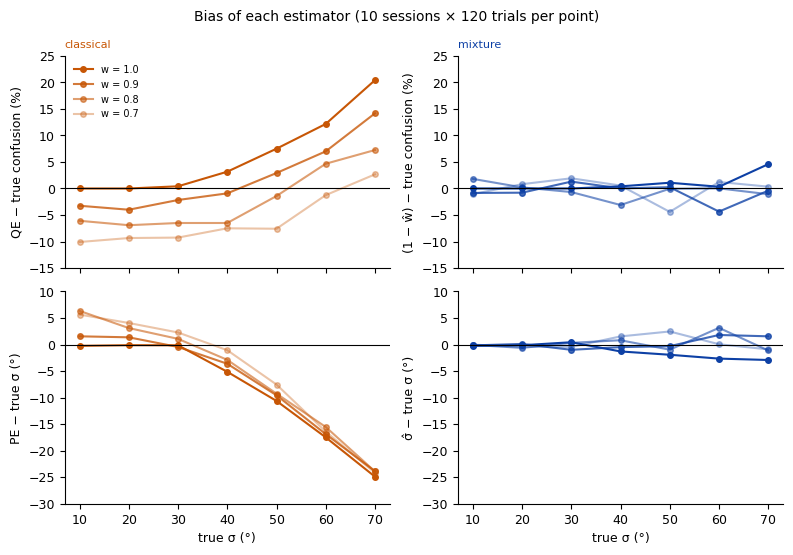

      bias_QE                                 bias_conf_mix                              
sigma    10.0 20.0 30.0 40.0 50.0  60.0  70.0          10.0 20.0 30.0 40.0 50.0 60.0 70.0
w                                                                                        
0.7     -10.1 -9.3 -9.3 -7.5 -7.6  -1.3   2.7          -1.1  0.8  1.9  0.6 -4.4  1.2  0.3
0.8      -6.1 -6.9 -6.5 -6.5 -1.4   4.7   7.3           1.8  0.2 -0.7 -3.1 -0.0  0.0 -1.1
0.9      -3.2 -4.0 -2.2 -0.9  2.9   7.0  14.2          -0.8 -0.8  1.3  0.0  0.2 -4.4 -0.4
1.0       0.0  0.0  0.4  3.2  7.5  12.2  20.4           0.0  0.0  0.0  0.4  1.1  0.3  4.6

      bias_PE                                  bias_sigma_mix                              
sigma    10.0 20.0 30.0 40.0  50.0  60.0  70.0           10.0 20.0 30.0 40.0 50.0 60.0 70.0
w                                                                                          
0.7       5.6  4.1  2.3 -1.1  -7.5 -16.4 -24.2           -0.0 -0.4 -0.5  1.5  2.5  0.1 -0.9
0

In [8]:
N_REP_D      = 10
w_grid_D     = np.array([1.0, 0.9, 0.8, 0.7])
sigma_grid_D = np.arange(10, 71, 10, dtype=float)

def _cell(w, s, seed):
    r   = np.random.default_rng(seed)
    out = []
    for _ in range(N_REP_D):
        t, e = simulate(w, s, r.choice(TARGET_POOL, N_TRIALS), r)
        out.append(score(t, e))
    d = pd.DataFrame(out).mean()
    return dict(w=w, sigma=s,
                bias_QE=d['QE'] - 100 * (1 - w),  bias_conf_mix=d['conf_mix'] - 100 * (1 - w),
                bias_PE=d['PE'] - s,              bias_sigma_mix=d['sigma_mix'] - s)

jobs_D  = [(w, s) for w in w_grid_D for s in sigma_grid_D]
sweep   = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(_cell)(w, s, SEED + 1000 + i) for i, (w, s) in enumerate(jobs_D))
sweep_df = pd.DataFrame(sweep)

fig, axes = plt.subplots(2, 2, figsize=(8, 5.6), sharex=True)
spec = [('bias_QE', 'QE − true confusion (%)',   C_ORANGE, axes[0, 0]),
        ('bias_conf_mix', '(1 − ŵ) − true confusion (%)', C_BLUE, axes[0, 1]),
        ('bias_PE', 'PE − true σ (°)',           C_ORANGE, axes[1, 0]),
        ('bias_sigma_mix', 'σ̂ − true σ (°)',    C_BLUE, axes[1, 1])]
alphas = np.linspace(1.0, 0.35, len(w_grid_D))
for col, ylabel, color, ax in spec:
    for w, a in zip(w_grid_D, alphas):
        d = sweep_df[sweep_df['w'] == w]
        ax.plot(d['sigma'], d[col], '-o', ms=4, color=color, alpha=a, label=f'w = {w}')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)
for ax in axes[1]: ax.set_xlabel('true σ (°)')
for ax in axes[0]: ax.set_ylim(-15, 25)
for ax in axes[1]: ax.set_ylim(-30, 10)
axes[0, 0].legend(fontsize=7, frameon=False)
axes[0, 0].set_title('classical', loc='left', fontsize=8, color=C_ORANGE)
axes[0, 1].set_title('mixture',   loc='left', fontsize=8, color=C_BLUE)
fig.suptitle(f'Bias of each estimator ({N_REP_D} sessions × {N_TRIALS} trials per point)', fontsize=10)
plt.tight_layout(); plt.show()

print(sweep_df.round(1).pivot(index='w', columns='sigma', values=['bias_QE', 'bias_conf_mix']).to_string())
print()
print(sweep_df.round(1).pivot(index='w', columns='sigma', values=['bias_PE', 'bias_sigma_mix']).to_string())

## Take-aways

- **QE inflates with scatter.** With no confusions at all, QE is ≈ 8 % at σ = 50° and ≈ 20 % at σ = 70°, because scatter alone crosses the 90° line.
- **QE misses confusions on elevated targets.** For targets at 60°/120° the mirrored response is only 60° away; at 90° the mirror is the target. On the AXD grid this hides roughly a third of true confusions; on an elevated-only grid it hides all of them.
- **PE saturates and absorbs hidden confusions.** Truncating at 90° caps PE near 45°: it under-reads σ by ≈ 10° at σ = 50° and ≈ 25° at σ = 70°, for every w. The sub-90° confusions of §2 push PE the other way for a precise listener (PE ≈ 33° for σ = 10°).
- **The two metrics are not separable.** Listeners with different `(w, σ)` share the same QE/PE fingerprint; the contour map shows the degeneracy directly.
- **The mixture model recovers both parameters** across the plane with small bias, because it models the mirror location rather than thresholding the error, and it degrades only where σ approaches the uniform limit (σ ≳ 60°, where any estimator loses information).